# SECTION 0

In [1]:
import subprocess
import sys

packages = [
    "pystac-client",
    "planetary-computer",
    "odc-stac",
    "rioxarray",
    "geopandas",
    "matplotlib",
    "numpy",
    "pandas",
    "scikit-learn",
    "shapely",
    "pyproj",
    "tqdm",
    "contextily",
    "matplotlib-scalebar"
]
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
print("All libraries installed successfully")

All libraries installed successfully


In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import rasterio.features as rfeatures
from pystac_client import Client
import planetary_computer
import odc.stac
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import ndimage
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar
import warnings
from tqdm import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')
print("All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"GeoPandas version: {gpd.__version__}")

All imports successful!
NumPy version: 2.4.4
Pandas version: 3.0.2
GeoPandas version: 1.1.3


# SECTION 1

Loaded site: stanislaus
Number of features: 1
Bounding Box: [-120.83   37.32 -120.75   37.4 ]


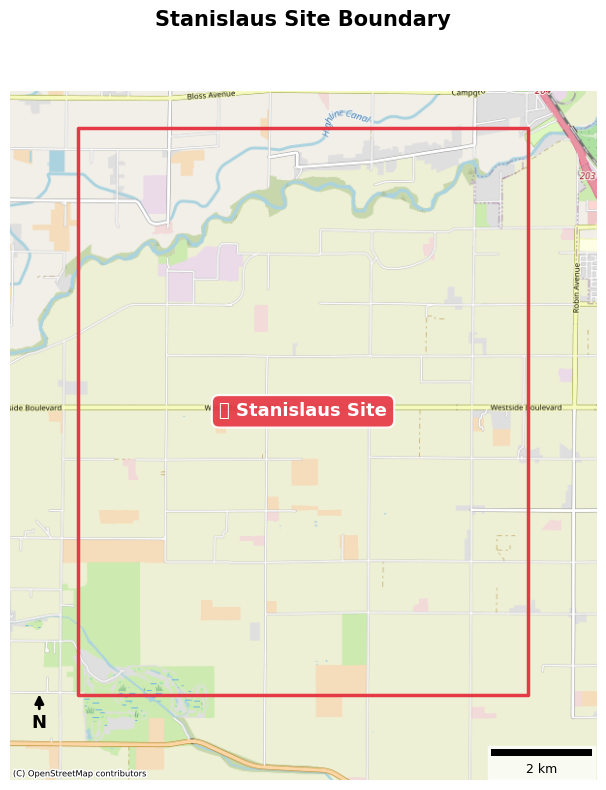

In [3]:
SITE_NAME           = "stanislaus"
SITE_FILE           = "/home/jovyan/work//_User-Persistent-Storage_CephBlock_/f3i-dc-2-sbosm/data/stanislaus_site_1.geojson"
UTM_CRS             = "EPSG:32610"
START_YEAR          = 2019
END_YEAR            = 2024
MONTHS              = [6, 7, 8]
MAX_CLOUD           = 20
MAX_SCENES_PER_YEAR = 2
OUTPUT_STRESS       = f"outputs/stress_maps/{SITE_NAME}_stress_map.png"
OUTPUT_TS           = f"outputs/time_series/{SITE_NAME}_vi_timeseries.png"

os.makedirs("outputs/stress_maps", exist_ok=True)
os.makedirs("outputs/time_series", exist_ok=True)

gdf = gpd.read_file(SITE_FILE)

if gdf.empty:
    raise ValueError("GeoJSON loaded but it is empty.")
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
gdf = gdf.to_crs("EPSG:4326")

print("Loaded site:", SITE_NAME)
print("Number of features:", len(gdf))
print("Bounding Box:", gdf.total_bounds)

gdf_webmercator = gdf.to_crs(epsg=3857)
bounds = gdf_webmercator.total_bounds
x_buf = (bounds[2] - bounds[0]) * 0.15
y_buf = (bounds[3] - bounds[1]) * 0.15
xlim  = (bounds[0] - x_buf, bounds[2] + x_buf)
ylim  = (bounds[1] - y_buf, bounds[3] + y_buf)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_webmercator.plot(ax=ax, facecolor="none", edgecolor="#E63946", linewidth=2.5, zorder=3)
ctx.add_basemap(ax, crs=gdf_webmercator.crs.to_string(),
                source=ctx.providers.OpenStreetMap.Mapnik, zoom="auto", attribution_size=6)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_axis_off()

centroid = gdf_webmercator.geometry.centroid.iloc[0]
ax.text(centroid.x, centroid.y, f"📍 {SITE_NAME.title()} Site",
        fontsize=13, fontweight="bold", color="white", ha="center", va="center", zorder=5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#E63946",
                  edgecolor="white", linewidth=1.5, alpha=0.92))

scalebar = ScaleBar(1, "m", length_fraction=0.2, location="lower right",
                    color="black", box_color="white", box_alpha=0.7,
                    font_properties={"size": 9})
ax.add_artist(scalebar)
ax.annotate("N", xy=(0.05, 0.12), xytext=(0.05, 0.07), xycoords="axes fraction",
            fontsize=13, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2), color="black")

plt.title(f"{SITE_NAME.title()} Site Boundary", fontsize=15, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(f"outputs/{SITE_NAME}_boundary.png", dpi=200, bbox_inches="tight")
plt.show()

# SECTION 2

In [4]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

bbox = gdf.total_bounds

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=f"{START_YEAR}-06-01/{END_YEAR}-08-31",
    query={"eo:cloud_cover": {"lt": MAX_CLOUD}},
)
items = list(search.items())
print("Total scenes found:", len(items))

def month_ok(item):
    dt = pd.to_datetime(item.datetime)
    return dt.month in MONTHS

filtered_items = [item for item in items if month_ok(item)]
print("Peak-season scenes found:", len(filtered_items))

def choose_best_items_for_year(items, year, max_items=2):
    year_items = []
    for item in items:
        dt = pd.to_datetime(item.datetime)
        if dt.year == year and dt.month in MONTHS:
            cloud = item.properties.get("eo:cloud_cover", 999)
            year_items.append((cloud, item))
    year_items.sort(key=lambda x: x[0])
    return [item for _, item in year_items[:max_items]]

def load_scene_stack(year_items, bbox):
    if not year_items:
        return None
    ds = odc.stac.load(
        year_items,
        bands=["B02", "B03", "B04", "B05", "B08", "B11"],
        bbox=bbox,
        crs=UTM_CRS,
        resolution=10,
        groupby="solar_day",
        chunks={},
        fail_on_error=False
    )
    if "time" not in ds.dims or ds.sizes.get("time", 0) == 0:
        return None
    ds = ds.astype("float32") / 10000.0
    return ds

Total scenes found: 579
Peak-season scenes found: 216


# SECTION 3

In [5]:
def orchard_mask_from_ds(ds, gdf_4326):
    raster_crs    = ds.odc.geobox.crs.to_epsg()
    gdf_projected = gdf_4326.to_crs(epsg=raster_crs)
    mask = rfeatures.geometry_mask(
        geometries=gdf_projected.geometry,
        transform=ds.odc.geobox.transform,
        out_shape=(ds.sizes["y"], ds.sizes["x"]),
        invert=True
    )
    return xr.DataArray(mask, coords={"y": ds.y, "x": ds.x}, dims=("y", "x"))

def compute_indices(ds):
    nir     = ds["B08"]
    red     = ds["B04"]
    green   = ds["B03"]
    blue    = ds["B02"]
    swir    = ds["B11"]
    rededge = ds["B05"]
    eps     = 1e-10
    ndvi = (nir - red)       / (nir + red      + eps)
    evi  = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + eps)
    ndmi = (nir - swir)      / (nir + swir     + eps)
    ndre = (nir - rededge)   / (nir + rededge  + eps)
    gci  = (nir / (green     + eps)) - 1
    return xr.Dataset({"NDVI": ndvi, "EVI": evi, "NDMI": ndmi, "NDRE": ndre, "GCI": gci})

def zscore_inside_orchard(da):
    mean_val = da.mean(skipna=True)
    std_val  = da.std(skipna=True)
    return (da - mean_val) / (std_val + 1e-10)

# SECTION 4

2019: selected scenes = 2
2020: selected scenes = 2
2021: selected scenes = 2
2022: selected scenes = 2
2023: selected scenes = 2
2024: selected scenes = 2
   year      NDVI       EVI      NDMI      NDRE       GCI
0  2019  0.506807  0.412788  0.089367  0.361965  3.098821
1  2020  0.500364  0.424446  0.088760  0.354986  2.991154
2  2021  0.488054  0.391293  0.076827  0.341840  3.021219
3  2022  0.350356  0.400279  0.074482  0.259504  1.412233
4  2023  0.372286  0.423927  0.097999  0.276794  1.474902
5  2024  0.371946  0.432346  0.093858  0.276368  1.488116


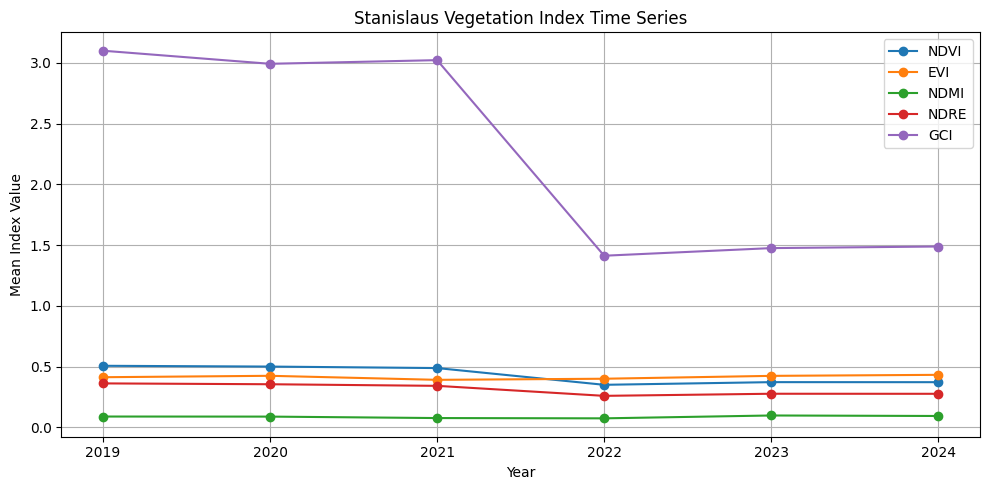

In [6]:
yearly_composites    = {}
yearly_summary       = []
yearly_stress_scores = []
 
for year in range(START_YEAR, END_YEAR + 1):
    year_items = choose_best_items_for_year(filtered_items, year, MAX_SCENES_PER_YEAR)
    print(f"{year}: selected scenes = {len(year_items)}")
 
    if len(year_items) == 0:
        continue
 
    ds = load_scene_stack(year_items, bbox)
    if ds is None:
        print(f"{year}: no usable raster data")
        continue
 
    orchard_mask = orchard_mask_from_ds(ds, gdf)
    indices = compute_indices(ds)

    comp = indices.median(dim="time", skipna=True)
    comp = comp.where(orchard_mask)           # Mask to site boundary
    yearly_composites[year] = comp
 
    row = {"year": year}
    for vi in ["NDVI", "EVI", "NDMI", "NDRE", "GCI"]:
        row[vi] = float(comp[vi].mean(skipna=True).values)
    yearly_summary.append(row)
 
    ndvi_stress = -zscore_inside_orchard(comp["NDVI"])
    evi_stress  = -zscore_inside_orchard(comp["EVI"])
    ndmi_stress = -zscore_inside_orchard(comp["NDMI"])
    ndre_stress = -zscore_inside_orchard(comp["NDRE"])
    gci_stress  = -zscore_inside_orchard(comp["GCI"])
 
    multi_index_stress = (
        ndvi_stress + evi_stress + ndmi_stress + ndre_stress + gci_stress
    ) / 5.0
    yearly_stress_scores.append(multi_index_stress)
 
if not yearly_summary:
    raise RuntimeError(
        "No yearly composites were created. "
        "Check the Stanislaus boundary, scene search, or raster loading."
    )
 
summary_df = pd.DataFrame(yearly_summary).sort_values("year")
print(summary_df)
 
plt.figure(figsize=(10, 5))
for vi in ["NDVI", "EVI", "NDMI", "NDRE", "GCI"]:
    plt.plot(summary_df["year"], summary_df[vi], marker="o", label=vi)
plt.title("Stanislaus Vegetation Index Time Series")
plt.xlabel("Year")
plt.ylabel("Mean Index Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_TS, dpi=300)
plt.show()
 
stress_stack      = xr.concat(yearly_stress_scores, dim="year")
persistence_score = stress_stack.mean(dim="year", skipna=True)
 
classified = xr.where(
    persistence_score > 1.0, 2,
    xr.where(persistence_score > 0.5, 1, 0)
)
classified = classified.where(~np.isnan(persistence_score))

# SECTION 5

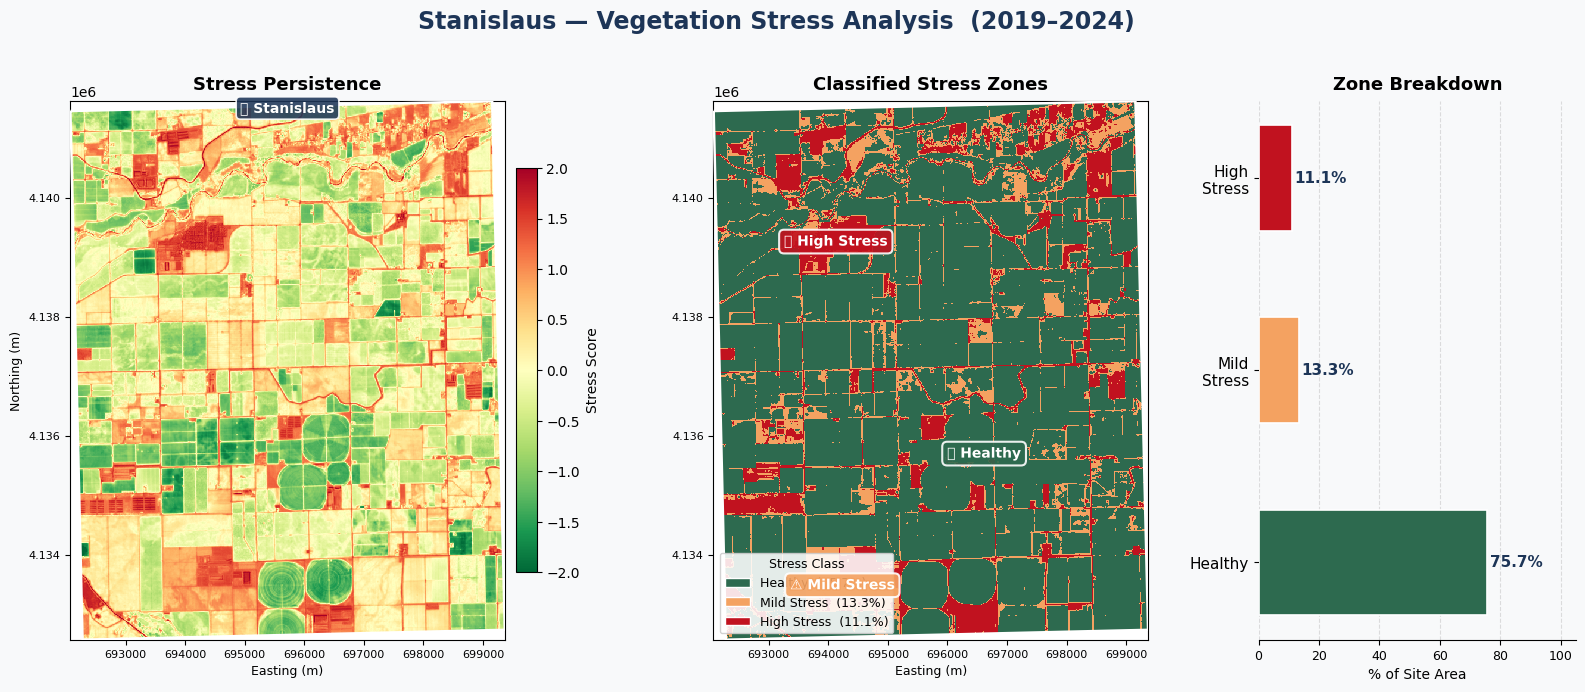


Zone breakdown — Stanislaus
  Healthy (0):     75.69%
  Mild stress (1): 13.25%
  High stress (2): 11.05%


In [7]:
def place_zone_labels(ax, data_array, class_value, label_text, color, fontsize=11):
    vals = data_array.values
    mask = (vals == class_value)
    if not mask.any():
        return
    labeled, num_features = ndimage.label(mask)
    if num_features == 0:
        return
    sizes         = ndimage.sum(mask, labeled, range(1, num_features + 1))
    largest_label = np.argmax(sizes) + 1
    region_mask   = (labeled == largest_label)
    cy, cx        = ndimage.center_of_mass(region_mask)
    cy, cx        = int(cy), int(cx)
    x_coord       = float(data_array.x[cx])
    y_coord       = float(data_array.y[cy])
    ax.text(
        x_coord, y_coord, label_text,
        fontsize=fontsize, fontweight="bold", color="white",
        ha="center", va="center", zorder=6,
        bbox=dict(boxstyle="round,pad=0.35", facecolor=color,
                  edgecolor="white", linewidth=1.5, alpha=0.90),
        path_effects=[pe.withStroke(linewidth=2, foreground=color)]
    )

vals        = classified.values.flatten()
vals        = vals[~np.isnan(vals)]
healthy_pct = np.mean(vals == 0) * 100
mild_pct    = np.mean(vals == 1) * 100
high_pct    = np.mean(vals == 2) * 100

gdf_proj = gdf.to_crs(UTM_CRS)

zone_colors = {
    0: "#2d6a4f",
    1: "#f4a261",
    2: "#c1121f",
}
cmap_discrete = mcolors.ListedColormap([zone_colors[0], zone_colors[1], zone_colors[2]])
norm_discrete = mcolors.BoundaryNorm([0, 0.5, 1.5, 2.5], cmap_discrete.N)

fig = plt.figure(figsize=(20, 7))
fig.patch.set_facecolor("#f8f9fa")
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.55], wspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

fig.suptitle(
    f"{SITE_NAME.title()} — Vegetation Stress Analysis  (2019–2024)",
    fontsize=17, fontweight="bold", y=1.01, color="#1d3557"
)

clipped = persistence_score.clip(-2, 2)
clipped.plot(ax=ax1, cmap="RdYlGn_r", vmin=-2, vmax=2, add_colorbar=True,
             cbar_kwargs={"label": "Stress Score", "shrink": 0.75, "pad": 0.02})
gdf_proj.boundary.plot(ax=ax1, color="white", linewidth=1.8, zorder=4)
x_mid = float(persistence_score.x.mean())
y_top = float(persistence_score.y.max())
ax1.text(x_mid, y_top, f"📍 {SITE_NAME.title()}",
         fontsize=10, fontweight="bold", color="white", ha="center", va="top", zorder=6,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#1d3557",
                   edgecolor="white", linewidth=1.2, alpha=0.88))
ax1.set_title("Stress Persistence", fontsize=13, fontweight="bold", pad=8)
ax1.set_xlabel("Easting (m)", fontsize=9)
ax1.set_ylabel("Northing (m)", fontsize=9)
ax1.tick_params(labelsize=8)

classified.plot(ax=ax2, cmap=cmap_discrete, norm=norm_discrete, add_colorbar=False)
gdf_proj.boundary.plot(ax=ax2, color="white", linewidth=1.8, zorder=4)

zone_labels = {
    0: ("✅ Healthy",     zone_colors[0]),
    1: ("⚠️ Mild Stress", zone_colors[1]),
    2: ("🔴 High Stress", zone_colors[2]),
}
for class_val, (label, color) in zone_labels.items():
    place_zone_labels(ax2, classified, class_val, label, color, fontsize=10)

legend_patches = [
    Patch(facecolor=zone_colors[0], edgecolor="white", label=f"Healthy  ({healthy_pct:.1f}%)"),
    Patch(facecolor=zone_colors[1], edgecolor="white", label=f"Mild Stress  ({mild_pct:.1f}%)"),
    Patch(facecolor=zone_colors[2], edgecolor="white", label=f"High Stress  ({high_pct:.1f}%)"),
]
ax2.legend(handles=legend_patches, loc="lower left", fontsize=9,
           framealpha=0.88, edgecolor="#cccccc", facecolor="white",
           title="Stress Class", title_fontsize=9)
ax2.set_title("Classified Stress Zones", fontsize=13, fontweight="bold", pad=8)
ax2.set_xlabel("Easting (m)", fontsize=9)
ax2.set_ylabel("")
ax2.tick_params(labelsize=8)

ax3.set_facecolor("#f8f9fa")
categories  = ["Healthy", "Mild\nStress", "High\nStress"]
percentages = [healthy_pct, mild_pct, high_pct]
colors      = [zone_colors[0], zone_colors[1], zone_colors[2]]

bars = ax3.barh(categories, percentages, color=colors,
                edgecolor="white", linewidth=1.2, height=0.55)
for bar, pct in zip(bars, percentages):
    ax3.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f"{pct:.1f}%", va="center", ha="left",
             fontsize=11, fontweight="bold", color="#1d3557")

ax3.set_xlim(0, 105)
ax3.set_xlabel("% of Site Area", fontsize=10)
ax3.set_title("Zone Breakdown", fontsize=13, fontweight="bold", pad=8)
ax3.tick_params(axis="y", labelsize=11)
ax3.tick_params(axis="x", labelsize=9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax3.xaxis.grid(True, linestyle="--", alpha=0.4)
ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUTPUT_STRESS, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\nZone breakdown — {SITE_NAME.title()}")
print(f"  Healthy (0):     {healthy_pct:.2f}%")
print(f"  Mild stress (1): {mild_pct:.2f}%")
print(f"  High stress (2): {high_pct:.2f}%")